# Euro Purchasing Power in Turkey

This notebook measures how the purchasing power of one euro in Turkey has changed over time. It combines the nominal EUR/TRY exchange rate with Turkey's HICP inflation indices, then normalizes the result so that **2024-08-30 = 100**.

## Method

The index is calculated as:

$$
\text{Euro purchasing power in Turkey} = \frac{\text{TRY per EUR}}{\text{Turkey HICP index}} \times 100
$$

The result is then normalized to the chosen base date. Values above 100 mean a euro buys more in Turkey than it did on the base date; values below 100 mean it buys less.

The notebook shows the all-items benchmark plus two tourist-relevant categories: transport services, and restaurants and hotels

In [32]:
from pathlib import Path
import math
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", message="Workbook contains no default style.*")

pd.options.display.float_format = "{:,.2f}".format

BASE_DATE = pd.Timestamp("2024-08-30")
HICP_TSV_FILE = Path("estat_prc_hicp_midx.tsv.gz")

CATEGORIES = [
    "All-items HICP",
    "Transport services",
    "Restaurants and hotels"
]

CATEGORY_CODES = {
    "All-items HICP": "CP00",
    "Transport services": "CP073",
    "Restaurants and hotels": "CP11"
}

ECB_FX_URL = (
    "https://data-api.ecb.europa.eu/service/data/"
    "EXR/D.TRY.EUR.SP00.A"
    "?format=csvdata"
)

## 1. EUR/TRY Exchange Rate

The ECB exchange-rate series is quoted as Turkish lira per one euro. A higher value means one euro exchanges into more lira.

In [33]:
fx_df = (
    pd.read_csv(ECB_FX_URL)
    .rename(columns={"TIME_PERIOD": "Date", "OBS_VALUE": "EUR_TRY"})
    [["Date", "EUR_TRY"]]
)

fx_df["Date"] = pd.to_datetime(fx_df["Date"])
fx_df["EUR_TRY"] = pd.to_numeric(fx_df["EUR_TRY"], errors="coerce")
fx_df = fx_df.dropna().sort_values("Date").reset_index(drop=True)

fx_df.tail()

,Date,EUR_TRY
7007,2026-05-19,52.96
7008,2026-05-20,52.88
7009,2026-05-21,52.91
7010,2026-05-22,53.01
7011,2026-05-25,53.23


## 2. Turkey Inflation Indices

The local Eurostat TSV archive stores monthly HICP index data by COICOP code. This section extracts Turkey's all-items index and the three requested category indices, then expands each monthly series to daily frequency by carrying the monthly value forward within each month.

In [34]:
raw_hicp_tsv = pd.read_csv(HICP_TSV_FILE, sep="\t", compression="gzip")
key_column = raw_hicp_tsv.columns[0]

hicp_dimensions = raw_hicp_tsv[key_column].str.split(",", expand=True)
hicp_dimensions.columns = ["freq", "unit", "coicop", "geo"]
hicp_dimensions = hicp_dimensions.apply(lambda col: col.str.strip())


def extract_hicp_series(
    coicop_code: str,
    geo: str = "TR",
    unit: str = "I15",
) -> pd.Series:
    """Extract one monthly Turkey HICP series from the loaded Eurostat TSV archive."""
    row_mask = (
        hicp_dimensions["freq"].eq("M")
        & hicp_dimensions["unit"].eq(unit)
        & hicp_dimensions["coicop"].eq(coicop_code)
        & hicp_dimensions["geo"].eq(geo)
    )

    values = raw_hicp_tsv.loc[row_mask].iloc[0, 1:]
    values.index = pd.to_datetime(values.index.str.strip(), format="%Y-%m")
    values = values.astype(str).str.extract(r"([-+]?\d*\.?\d+)")[0]
    return pd.to_numeric(values, errors="coerce").dropna()


def monthly_to_daily(series: pd.Series, name: str) -> pd.Series:
    daily_index = pd.date_range(
        series.index.min(),
        series.index.max() + pd.offsets.MonthEnd(0),
        freq="D",
        name="Date",
    )
    return series.reindex(daily_index).ffill().rename(name)


daily_hicp_series = []
for category in CATEGORIES:
    monthly_series = extract_hicp_series(CATEGORY_CODES[category])
    daily_hicp_series.append(monthly_to_daily(monthly_series, category))

hicp_df = pd.concat(daily_hicp_series, axis=1).reset_index()
hicp_df.tail()

,Date,All-items HICP,Transport services,Restaurants and hotels
10953,2025-12-27,"1,348.17","1,594.78","1,875.71"
10954,2025-12-28,"1,348.17","1,594.78","1,875.71"
10955,2025-12-29,"1,348.17","1,594.78","1,875.71"
10956,2025-12-30,"1,348.17","1,594.78","1,875.71"
10957,2025-12-31,"1,348.17","1,594.78","1,875.71"


## 3. Purchasing Power Indices

This combines the FX rate and each Turkey inflation index. The raw purchasing-power measure rises when the euro strengthens against the lira and falls when Turkish prices rise.

In [35]:
pp_df = pd.merge(fx_df, hicp_df, on="Date", how="inner")
pp_columns = {}
base_dates = {}
summary_rows = []

for category in CATEGORIES:
    real_col = f"Real_EUR_TRY__{category}"
    index_col = f"PurchasingPowerIndex__{category}"

    pp_df[real_col] = pp_df["EUR_TRY"] / pp_df[category] * 100

    base_rows = pp_df.loc[pp_df["Date"].le(BASE_DATE)].dropna(subset=[real_col])

    base_row = base_rows.iloc[-1]
    base_dates[category] = base_row["Date"]
    pp_df[index_col] = pp_df[real_col] / base_row[real_col] * 100
    pp_columns[category] = index_col

    latest = pp_df.dropna(subset=[index_col]).iloc[-1]
    summary_rows.append({
        "Category": category,
        "Latest date": latest["Date"],
        "Index": latest[index_col],
        "Change from base": latest[index_col] - 100,
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,Category,Latest date,Index,Change from base
0,All-items HICP,2025-12-31,93.30,-6.70
1,Transport services,2025-12-31,91.28,-8.72
2,Restaurants and hotels,2025-12-31,93.64,-6.36


## 4. Charts

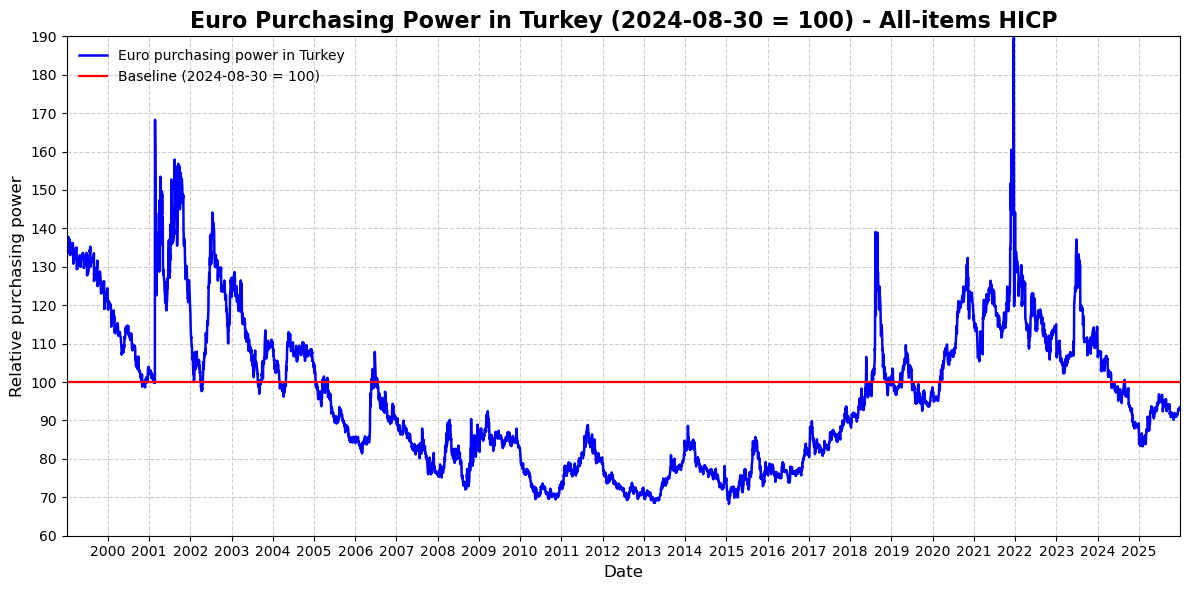

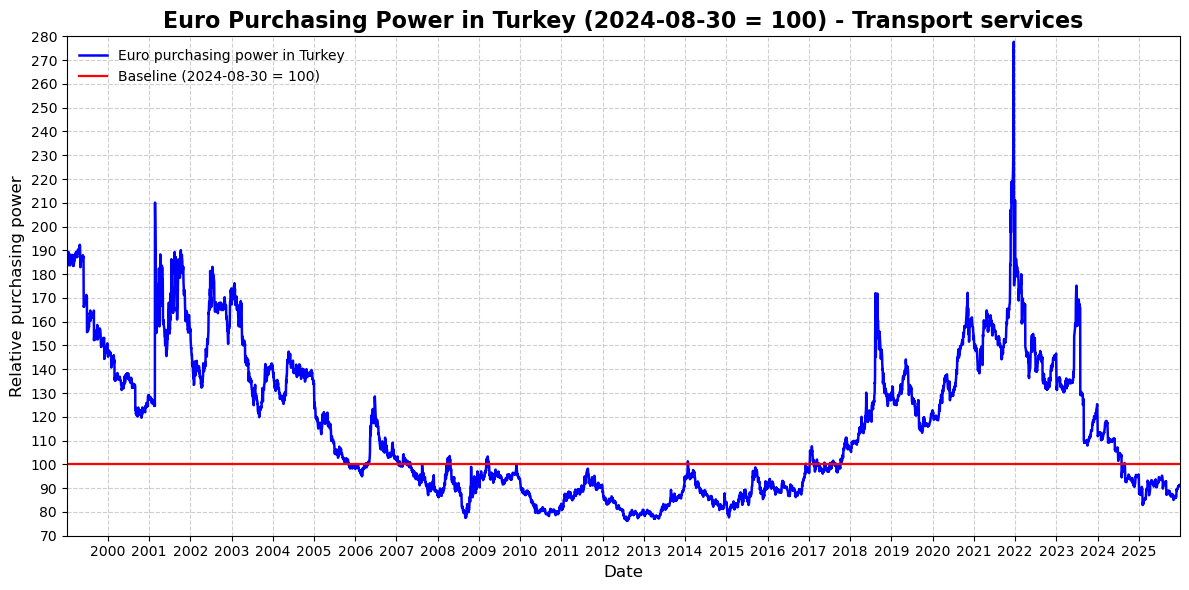

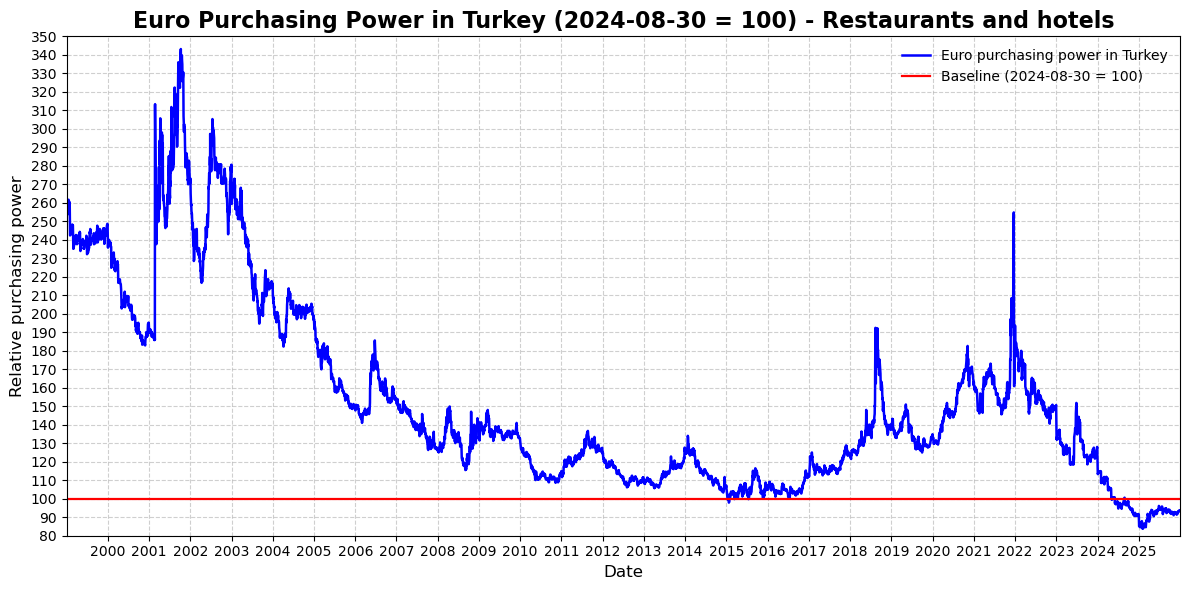

In [36]:
def plot_purchasing_power(category: str) -> None:
    index_col = pp_columns[category]
    data = pp_df.dropna(subset=[index_col])

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(
        data["Date"],
        data[index_col],
        color="blue",
        linewidth=1.8,
        label="Euro purchasing power in Turkey",
    )
    ax.axhline(
        100,
        color="red",
        linewidth=1.6,
        label=f"Baseline ({base_dates[category]:%Y-%m-%d} = 100)",
    )

    min_y = math.floor(data[index_col].min() / 10) * 10
    max_y = math.ceil(data[index_col].max() / 10) * 10
    ax.set_ylim(min_y, max_y)
    ax.set_yticks(range(min_y, max_y + 1, 10))

    # Remove the default padding before the first point and after the last point.
    ax.set_xlim(data["Date"].min(), data["Date"].max())
    ax.margins(x=0)

    # Put a tick at every year and keep each label centered under its tick mark.
    ax.xaxis.set_major_locator(mdates.YearLocator(1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    for label in ax.get_xticklabels():
        label.set_ha("center")
        label.set_rotation(0)

    ax.set_title(
        f"Euro Purchasing Power in Turkey ({base_dates[category]:%Y-%m-%d} = 100) - {category}",
        fontsize=16,
        fontweight="bold",
    )
    ax.set_xlabel("Date", fontsize=12)
    ax.set_ylabel("Relative purchasing power", fontsize=12)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()


for category in CATEGORIES:
    plot_purchasing_power(category)

## 5. Interpretation for a Euro Area Tourist

The red line is the reference point: on the base date, the index equals 100. The blue line shows the real purchasing power of a euro in Turkey after adjusting for Turkish inflation in that spending category. From a tourist's perspective, values above 100 mean that category is cheaper than on the base date; values below 100 mean it is more expensive in euro purchasing-power terms.

As of the latest available date in the merged data, the category-specific readings are:

- All-items HICP: 93.3, or about 6.7% less purchasing power than on 2024-08-30.
- Transport services: 91.3, or about 8.7% less purchasing power than on 2024-08-30.
- Restaurants and hotels: 93.6, or about 6.4% less purchasing power than on 2024-08-30.

For a Euro Area tourist, the most favorable category in this set is Restaurants and hotels, while the least favorable is Transport services. The useful point is that the exchange rate alone can be misleading: a weaker lira helps visitors, but local inflation can offset that gain differently across meals, hotels, transport, and drinks.